<a href="https://colab.research.google.com/github/academyExcelleance/ai-mlops-learning/blob/master/M2_NB_MiniProject_1_Face_Mask_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in AI and MLOps
## A programme by IISc and TalentSprint
### Mini Project: Face Mask Detection using Convolutional Neural Networks

## Learning Objectives

At the end of the experiment, you will be able to :

* load the image dataset using ImageDataGenerator from the path directory
* perform data augmentation on the fly and create  batches of the dataset
* build the convolutional neural networks for classification problem
* visualize & interpret what CNN layers learn
* use the transfer learning (pre-trained models) for classification problems

## Introduction

This project uses a Deep Neural Network, more specifically a Convolutional Neural Network, to differentiate between images of people, with masks, without masks and incorrectly placed masks. Manually built and pretrained networks will be used to perform this classification task.

**Face-Mask-Detection-Using-CNN**

* Outbreak of the Coronavirus pandemic has created various changes in the lifestyle of everyone around the world.
* Among these changes, wearing a mask has been very vital to every individual.
* Detection of people who are not wearing masks is a challenge due to the large populations.
* This face mask detection project can be used in schools, hospitals, banks, airports etc as a digitalized scanning tool.
  - The technique of detecting people’s faces and segregating them into three classes namely the people with masks and people without masks and partial masks is done with the help of image processing and deep learning.
* With the help of this project, a person who is monitoring the face mask status for a particular firm can be seated in a remote area and still monitor efficiently and give instructions accordingly.

![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/dataset-images-with-mask.jpg)

## Dataset

The data for this mini-project is collected from various sources including the masked images from internet and general frontal face images considered as without mask. This dataset consists of 5029 train images and 1059 test images with 3 classes `with_mask`, `without_mask` and `partial_mask`

Many people are not correctly wearing their masks due to bad practices, bad behaviors or vulnerability of individuals (e.g., children, old people). For these reasons, several mask wearing campaigns intend to sensitize people about this problem and good practices. In this sense, this work proposes three types of masked face detection dataset
  
- Without Mask/ With Mask/ Partial Mask
  
Note that this dataset contains some annotated (artificially generated) masks to augment the 'masked' data category.

## Problem Statement

To build and implement a Convolutional Neural Network model to classify between masked/unmasked/partially masked faces.

In [2]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/MP2_FaceMask_Dataset.zip
!unzip -qq MP2_FaceMask_Dataset.zip
print("Data Downloaded Successfuly!!")

Data Downloaded Successfuly!!


## Grading = 10 Points

### Import Required packages

In [3]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense,Dropout
from keras.models import Model, load_model
from keras.callbacks import EarlyStopping, TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import numpy as np
import pandas as pd
import PIL
from matplotlib import pyplot as plt
from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
import tensorflow as tf
from tensorflow import keras
import glob, os

# Part-A [5-Marks]

### Analyzing the shape and distribution of datasets [1 Mark]

Store the list of the paths from the training dataset for images of partial-mask, with_mask, and without_mask in variables partial, on, and off respectively. Hint : [Check the 'glob' section.](https://realpython.com/working-with-files-in-python/)

In [3]:
# YOUR CODE HERE
import glob, os

# Define the base directory
image_base_dir = '/content/MP2_FaceMask_Dataset/train'

# Store paths for partial-mask
partial = glob.glob(os.path.join(image_base_dir, 'partial_mask', '*.jpg'))

# Store paths for with_mask
on = glob.glob(os.path.join(image_base_dir, 'with_mask', '*.jpg'))

# Store paths for without_mask
off = glob.glob(os.path.join(image_base_dir, 'without_mask', '*.jpg'))

print(f"Number of partial-mask images: {len(partial)}")
print(f"Number of with_mask images: {len(on)}")
print(f"Number of without_mask images: {len(off)}")
print(f"All images size: {len(partial) + len(on) + len(off) }")

Number of partial-mask images: 1294
Number of with_mask images: 1523
Number of without_mask images: 2127
All images size: 4944


Store paths of all three types of images in one variable. Check and store the height and width of each image.

Hint: Use PIL(PIL.Image.open) library to open the image from the path, convert it into a NumPy array and check for shape.  

In [5]:
# YOUR CODE HERE

all_images = glob.glob(os.path.join(image_base_dir,"*", "*.jpg"))

print(f"All image size: {len(all_images)} ")

All image size: 4944 


In [6]:
# YOUR CODE HERE
from PIL import Image

for image_path in all_images:
    print(image_path)
    break
all_width  = []
all_height = []
all_image_shape = []
for image_path in all_images:
    with Image.open(image_path) as img:
        img_array = np.array(img)
        #width, height = img.size
        height, width, channel = img_array.shape
        all_width.append(width)
        all_height.append(height)
        all_image_shape.append(img_array)

/content/MP2_FaceMask_Dataset/train/without_mask/augmented_image_238.jpg


Discuss the distribution of images. Calculate and display max, min and average of height and width of all images.

Mean across height of all images in train set is: 438.4906957928803
Mean across width of all mages in train set is: 453.7902508090615


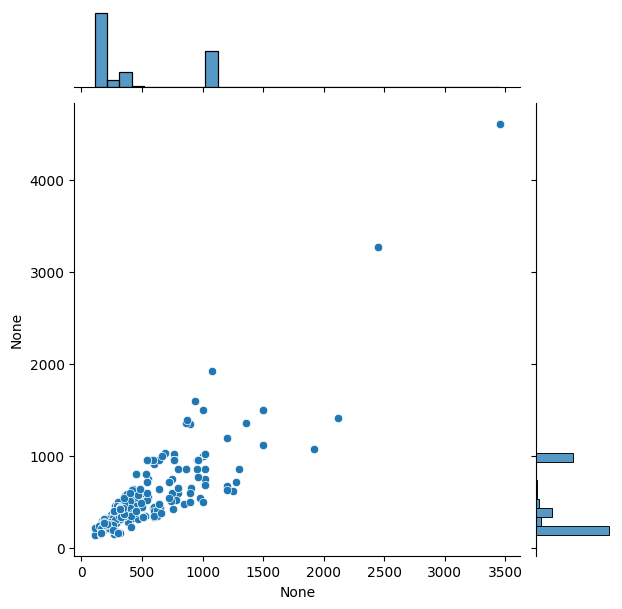

In [7]:
import seaborn as sns
# Plot the distribution of image dimensions
sns.jointplot(x=all_width, y=all_height)
print("Mean across height of all images in train set is:", np.mean(all_width))
print("Mean across width of all mages in train set is:", np.mean(all_height))

### Visualize the sample images of each class before augmentation [1 Mark]

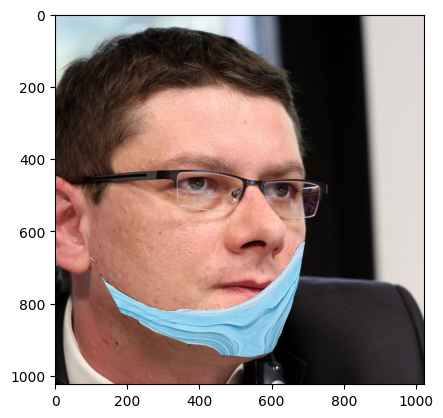

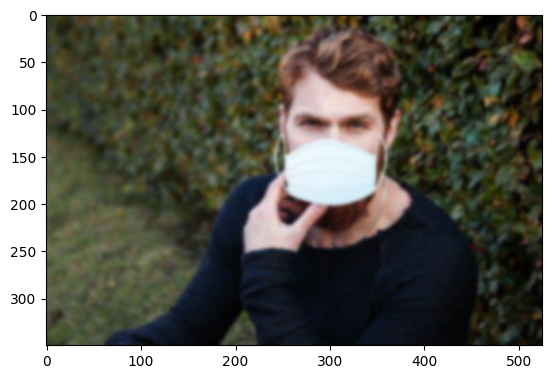

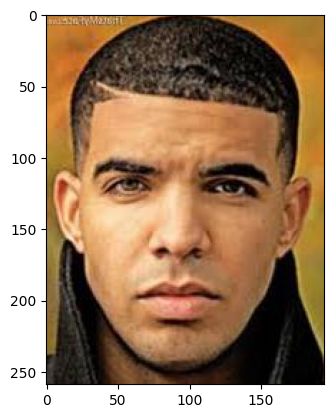

In [8]:
# YOUR CODE HERE

image_path = partial[0]
img = Image.open(image_path)
img_array = np.array(img)
plt.imshow(img_array)
plt.show()

image_path = on[0]
img = Image.open(image_path)
img_array = np.array(img)
plt.imshow(img_array)
plt.show()

image_path = off[0]
img = Image.open(image_path)
img_array = np.array(img)
plt.imshow(img_array)
plt.show()

In [ ]:
# YOUR CODE HERE

### Load the images using ImageDataGenerator [1 Mark]

There are two main steps involved in creating the generator.
1. Instantiate ImageDataGenerator with required arguments to create an object
2. Use the `flow_from_directory` command depending on how your data is stored on disk. This is the command that will allow you to generate and get access to batches of data on the fly.

Hint: [link](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator)

In [4]:
TRAINING_DIR = "/content/MP2_FaceMask_Dataset/train/"
VALIDATION_DIR = "/content/MP2_FaceMask_Dataset/test/"



In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values to [0, 1]
    rotation_range=20,      # Randomly rotate images by up to 20 degrees
    width_shift_range=0.2,   # Randomly shift images horizontally by up to 20% of the width
    height_shift_range=0.2,  # Randomly shift images vertically by up to 20% of the height
    shear_range=0.2,        # Apply random shear transformations
    zoom_range=0.2,         # Randomly zoom in/out on images
    horizontal_flip=True,   # Randomly flip images horizontally
    fill_mode='nearest'     # Fill in missing pixels using the nearest value
)
train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,  # Directory containing training images
    target_size=(224, 224),    # Resize images to 150x150 pixels
    batch_size=32,            # Generate batches of 32 images
    class_mode='categorical'  # Use 'categorical' for multi-class classification
)

validation_generator = train_datagen.flow_from_directory(
    VALIDATION_DIR,  # Directory containing training images
    target_size=(224, 224),    # Resize images to 150x150 pixels
    batch_size=32,            # Generate batches of 32 images
    class_mode='categorical'  # Use 'categorical' for multi-class classification
)

Found 5029 images belonging to 3 classes.
Found 1259 images belonging to 3 classes.


**Check** class indices

In [20]:
# YOUR CODE HERE
print(train_generator.class_indices)


{'partial_mask': 0, 'with_mask': 1, 'without_mask': 2}


Check the shape of the image from train_generator

In [21]:
# YOUR CODE HERE
# Get a batch of data from the generator
x_batch, y_batch = next(train_generator)

# Check the shape of the first image in the batch
print("Shape of a single image in the batch:", x_batch[0].shape)


Shape of a single image in the batch: (224, 224, 3)


In [ ]:
# YOUR CODE HERE

### Visualize a few sample images using data generator [1 Mark]

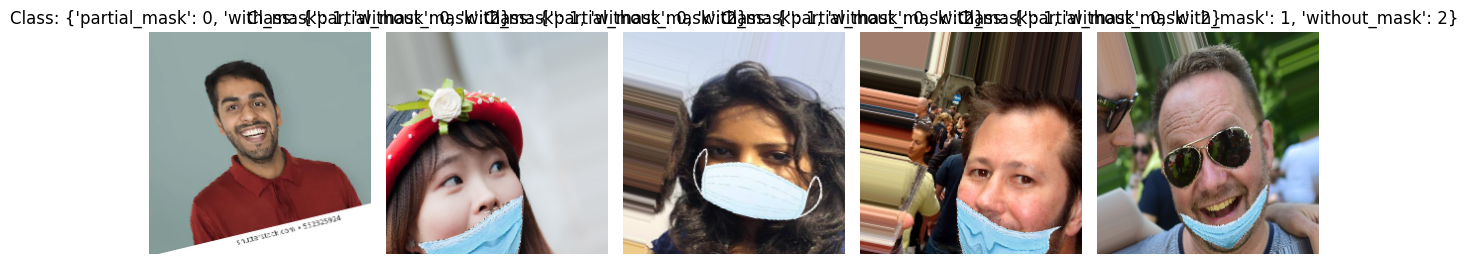

In [22]:
# YOUR CODE HERimport matplotlib.pyplot as plt

# Get a batch of data from the generator
x_batch, y_batch = next(train_generator)

# Plot a few images from the batch
plt.figure(figsize=(12, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_batch[i])  # Display the image
    plt.axis('off')
    plt.title(f"Class: {train_generator.class_indices}")  # Show the class index

plt.tight_layout()
plt.show()


In [ ]:
# YOUR CODE HERE

## Build the CNN model using Keras [1 Mark]



**Convolutional Neural Network:** A neural network in which at least one layer is a convolutional layer. A typical convolutional neural network consists of some combination of the following layers:

* convolutional layers
* pooling layers
* dense layers


**Conv2D**  

Passing an image with input shape of 3-D and to calculate the output:

 $O = \frac{n - f + 2p}{s} + 1$

 where

 $n$ = image dimension

 $f$ = filter size

 $p$ = padding

 $s$ = stride

**MaxPool**

The resulting output, when using the "valid" padding option, has a spatial shape (number of rows or columns) of:

O = `math.floor`$(\frac{input shape - pool size)}{ strides}) + 1$ (when input shape >= pool size)

The resulting output shape when using the "same" padding option is:

O = `math.floor`$(\frac{input shape - 1}{strides}) + 1$

by default, stride = None, so stride is same as pool size

Task-flow
* Initialize the network of convolution, maxpooling and dense layers
* Define the optimizer and loss functions
* Fit the model and evaluate the model

**model 1 with 2 convolutional (feature representation) and 2 maxpool layers (down sampling) and 2 dense layers for classification.**

In [32]:
model1 = Sequential([
    Conv2D(100, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(100, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
# Compile the model
model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])





/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# YOUR CODE HERE
#Note: Applying a convolution to an image will make it smaller (if no padding).
#Convolving a 3x3 filter over images means we’ll lose a single pixel on all sides (2 in total).
#In the given case, sliding a 3x3 filter over a 224x224 image results in a 222x222 image

Fit the data to the model

In [25]:
# YOUR CODE HERE
history1 = model1.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.3618 - loss: 3.0485

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_2" is incompatible with the layer: expected axis -1 of input shape to have value 291600, but received input with shape (None, 129600)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 150, 150, 3), dtype=float32)
  • training=False
  • mask=None

Plot training and validation loss

In [ ]:
# YOUR CODE HERE
accuracy = history1.history["accuracy"]
loss = history1.history["loss"]
val_accuracy = history1.history["val_accuracy"]
val_loss = history1.history["val_loss"]

epochs = range(1, len(accuracy)+ 1)
print(accuracy)

plt.plot(epochs,accuracy, "bo", label = "Training Accuracy")
plt.plot(epochs,val_accuracy, "b", label = "Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "bo", label = "Training Loss")
plt.plot(epochs,val_loss, "b", label = "Validation Loss")
plt.title("Loss vs Validation Loss")
plt.legend()
plt.figure()

**model 2 with few more conv layers**

Task-flow
* Initialize the network of convolution, maxpooling and dense layers
* Define the optimizer and loss functions
* Define callback list
* Fit the model and evaluate the model

Define the model

In [8]:
# YOUR CODE HERE
model2 = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(3, activation='softmax')
])

In [6]:
# Define the input
input_layer = Input(shape=(224, 224, 3))

# Add convolutional and pooling layers
x = Conv2D(32, (3, 3), activation='relu')(input_layer)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

# Flatten the feature map and add dense layers
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
output_layer = Dense(3, activation='softmax')(x)

# Create the model
model2 = Model(inputs=input_layer, outputs=output_layer)

In [7]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,397,635 (169.36 MB)

 Trainable params: 44,397,635 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

Compile the model

In [8]:
# YOUR CODE HERE
model2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Define Callbacks

In [8]:
# YOUR CODE HERE
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss'),
    ModelCheckpoint('face_mask_model.keras', save_best_only=True)
]

Fit the data to the model

In [9]:
# YOUR CODE HERE
history2 = model2.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


158/158 ━━━━━━━━━━━━━━━━━━━━ 102s 589ms/step - accuracy: 0.6441 - loss: 0.9723 - val_accuracy: 0.8983 - val_loss: 0.2937
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 95s 585ms/step - accuracy: 0.9108 - loss: 0.2475 - val_accuracy: 0.9365 - val_loss: 0.2029
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 88s 540ms/step - accuracy: 0.9377 - loss: 0.1802 - val_accuracy: 0.9333 - val_loss: 0.2107
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 87s 534ms/step - accuracy: 0.9432 - loss: 0.1634 - val_accuracy: 0.9142 - val_loss: 0.2689
Epoch 5/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 96s 581ms/step - accuracy: 0.9375 - loss: 0.1783 - val_accuracy: 0.9436 - val_loss: 0.1765
Epoch 6/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 96s 593ms/step - accuracy: 0.9460 - loss: 0.1568 - val_accuracy: 0.9492 - val_loss: 0.1551
Epoch 7/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 98s 598ms/step - accuracy: 0.9529 - loss: 0.1483 - val_accuracy: 0.9579 - val_loss: 0.1261
Epoch 8/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 98s 608ms/step - accuracy: 0.9491 - loss: 0.1502 - va

Plot training and validation loss

[0.78425133228302, 0.9172797799110413, 0.9411413669586182, 0.9469079375267029, 0.9419367909431458, 0.9479021430015564, 0.9548618197441101, 0.9578444957733154, 0.9600318074226379, 0.9592364430427551]


<Figure size 640x480 with 0 Axes>

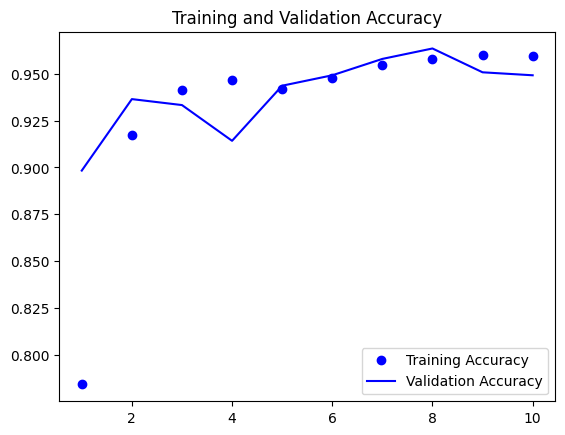

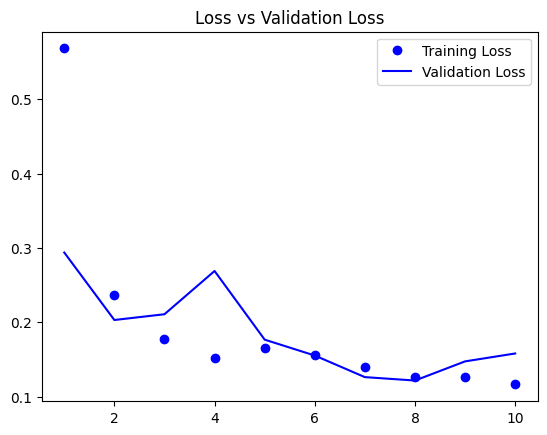

<Figure size 640x480 with 0 Axes>

In [10]:
# YOUR CODE HERE
accuracy = history2.history["accuracy"]
loss = history2.history["loss"]
val_accuracy = history2.history["val_accuracy"]
val_loss = history2.history["val_loss"]

epochs = range(1, len(accuracy)+ 1)
print(accuracy)

plt.plot(epochs,accuracy, "bo", label = "Training Accuracy")
plt.plot(epochs,val_accuracy, "b", label = "Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "bo", label = "Training Loss")
plt.plot(epochs,val_loss, "b", label = "Validation Loss")
plt.title("Loss vs Validation Loss")
plt.legend()
plt.figure()

## Prediction on a random test image

In [13]:
# YOUR CODE HERE
from tensorflow.keras.preprocessing import image

test_image_path = '/content/MP2_FaceMask_Dataset/test/with_mask/111-with-mask.jpg'  # Replace with the path to your test image
img = image.load_img(test_image_path, target_size=(224, 224))  # Resize to match model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize pixel values
prediction = model2.predict(img_array)  # 'model' is your trained model (model1 or model2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


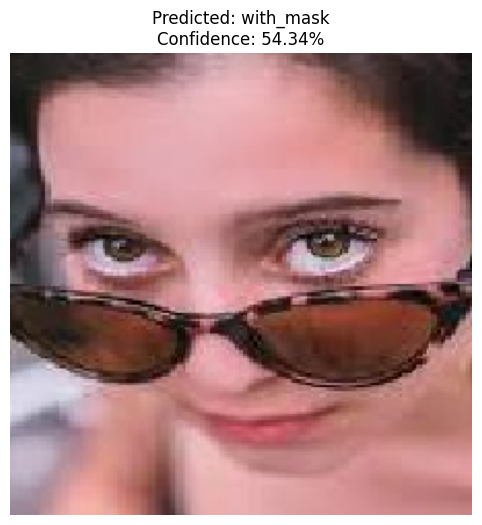

partial_mask: 0.05%
with_mask: 54.34%
without_mask: 45.61%


In [15]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import random
def predict_mask(model, image_path):
    # Load and preprocess the image
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = img_array / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make prediction
    prediction = model.predict(img_array)

    # Get class labels
    classes = ['partial_mask', 'with_mask', 'without_mask']
    predicted_class = classes[np.argmax(prediction[0])]
    confidence = np.max(prediction[0])

    # Display results
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f'Predicted: {predicted_class}\nConfidence: {confidence:.2%}')
    plt.axis('off')
    plt.show()

    # Print detailed probabilities
    for class_name, prob in zip(classes, prediction[0]):
        print(f'{class_name}: {prob:.2%}')

# Select a random test image
test_paths = glob.glob(os.path.join('/content/MP2_FaceMask_Dataset/test', '*/*.jpg'))
random_test_image = random.choice(test_paths)

# Make prediction
predict_mask(model2, random_test_image)

# Part-B [5-Marks]

## Visualization [2 Marks]

Define a function 'get_img_array' that takes two parameters image path and target size. It returns the converted image to array.

Display this image.

Hint:: Consider AST3 for visualization.

In [9]:
# YOUR CODE HERE
from keras.preprocessing.image import load_img, img_to_array

def get_img_array(img_path, img_size):
    return img_to_array(load_img(img_path, target_size = img_size))



In [10]:
import matplotlib.pyplot as plt
test_paths = glob.glob(os.path.join('/content/MP2_FaceMask_Dataset/test', '*/*.jpg'))
img_path = random.choice(test_paths)
#img_path = "/content/MP2_FaceMask_Dataset/train/partial_mask/51000_Mask_Mouth_Chin.jpg"
target_size = (244,244,3)
img_array = get_img_array(img_path,target_size)

NameError: name 'random' is not defined

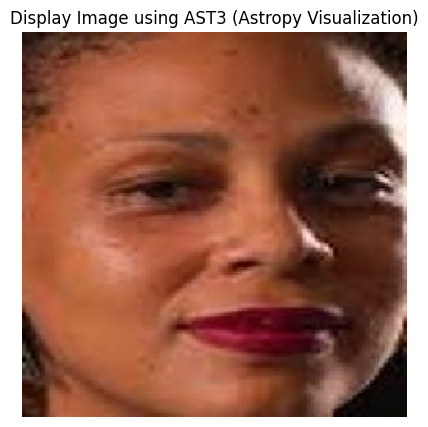

In [21]:
from astropy.visualization import simple_norm

norm = simple_norm(img_array, 'linear')  # You can also use 'log', 'sqrt', etc.

#img = load_img(img_path,target_size=target_size)

# Display the image
plt.figure(figsize=(5, 5))
#plt.imshow(img)
plt.imshow(img_array.astype('uint8'), norm=norm)
plt.axis('off')  # Hide axes for better visualization
plt.title("Display Image using AST3 (Astropy Visualization)")
plt.show()

## Instantiating a model that returns "layer activations"

Hint:: Use 'keras.model' to define this model.

In [28]:
from tensorflow.keras.models import load_model

model = load_model("/content/face_mask_model.keras")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 133,192,907 (508.09 MB)

 Trainable params: 44,397,635 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,795,272 (338.73 MB)

In [11]:
# Instantiating a model that returns "layer activations"
# YOUR CODE HERE
from tensorflow.keras import layers

activation_layers = []

for layer in model2.layers:
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)):
        activation_layers.append(layer.output)

activation_layers

activation_model = keras.Model(inputs = model2.input, outputs = activation_layers)


Once the activation model is defined, predict the image tensor created using this model.

In [ ]:
# Compute layer activations
# YOUR CODE HERE
predictions_based_on_activation_model = activation_model.predic(img_array)

## Visualize first feature map

In [ ]:
# Visualise activation

first_feature_map = predictions_based_on_activation_model[0]
print(first_feature_map.shape)
plt.imshow(first_feature_map[0, :, :, 0], cmap='viridis')  # Display the first channel of the first feature map
plt.show()
# YOUR CODE HERE

## Visualize feature map after each layer

In [ ]:
# YOUR CODE HERE

Successive feature maps are of smaller dimensions but scaled to be the same size during visualization.

## Visualise all the feature maps of all the layers

In [ ]:
# Post-processing code - only visualizaton
# Visualizing every channel in every intermediate activation
# YOUR CODE HERE
# YOUR CODE HERE

# ConvNet Filters [1 Mark]

## Print the names of  conv and MaxPooling layers.

Hint:: 'model2.layer'

In [ ]:
# YOUR CODE HERE

## Create a feature extractor model

In [ ]:
# YOUR CODE HERE
# Check the model summary
# YOUR CODE HERE

## Use the feature extractor model to extract feature out of the image tensor.

In [ ]:
# YOUR CODE HERE

Define a function 'compute_loss' it takes two arguments, image and filter index. It returns the filter activation using 'tf.reduce_mean'.

In [ ]:
# YOUR CODE HERE

## Loss maximization via stochastic gradient ascent.
Define a function to implement this step.

In [ ]:
@tf.function
# YOUR CODE HERE

## Define a function to generate filter visualizations

This function uses gradient ascent to generate an image that maximizes the activation of a given filter in a CNN.

In [ ]:
# YOUR CODE HERE

## Define a function to convert a tensor into a valid image

In [ ]:
# YOUR CODE HERE

Generate a list of images, where each image in the list represents the activation pattern of a particular filter in the given layer.

In [ ]:
# Post processing- Just visualization
# Generating a grid of all filter response patterns in a layer

# YOUR CODE HERE

Stitch together all the images in the 'all_images' list and save the resulting image as a PNG file. The resulting image shows a grid of all the filter activation patterns in the given layer.

In [ ]:
# YOUR CODE HERE

Display the images

In [ ]:
# YOUR CODE HERE

All the steps discussed in visualization section can be easily understood from AST3.

## Transfer Learning [2 Marks]

Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.

A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task.

The intuition behind transfer learning for image classification is that if a model is trained on a large and general enough dataset, this model will effectively serve as a generic model of the visual world. You can then take advantage of these learned feature maps without having to start from scratch by training a large model on a large dataset.

For eg. Using VGG16, we remove the last layer which takes a probability for each of the 1000 classes in the ImageNet and replaces it with a layer that takes 3 probabilities in our case.

### Use the pre-trained models ([VGG16](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/VGG16) or [ResNet50](https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/ResNet50))

* Load the pre-trained model
* Fit and evaluate the data

Hint: [How to use pre-trained model](https://drive.google.com/file/d/1d5WSWQmdVYYcJhvhMcZMoK5-BPOC1B_7/view?usp=sharing)

#### Expected accuracy: More than 90%

Task-flow
* Initialize the network with the weights of Imagenet
* Fine tune the network by modifying fully connected layers.
* Re-train the model with our problem data

#### VGG16

Define the pre-trained vgg model with dense layers.

Display the model summary

In [ ]:
# YOUR CODE HERE

In [ ]:
# Compile the model
# YOUR CODE HERE

Fit the data to the model

In [ ]:
# YOUR CODE HERE

Plot training and validation loss

In [ ]:
# YOUR CODE HERE

#### ResNet50

Define the pre-trained resnet model with dense layers

In [ ]:
# YOUR CODE HERE

Fit the data to the model

In [ ]:
# YOUR CODE HERE

Plot the validation and training loss

In [ ]:
# YOUR CODE HERE

### Capture the live image using the below code cell and predict

In [ ]:
#@title Capture the photo
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))
  display(Image(filename))
except Exception as err:
  print(str(err))

After executing above cell and capturing the photo, load the captured photo and predict with model.

**Note:**
* Convert the image to numpy array and resize to the shape which model accept.
* Extend the dimension (to 4-D shape) of an image, as the model is trained on a batch of inputs.

In [ ]:
# Make a prediction using model that is created by making use of transer learning technique
# YOUR CODE HERE

### Report Analysis

- Compare the accuracies for the Pre-trained vs CNN models
- Which model detects the mask/no mask/ partial mask more accurately with the live pictures?
- What process was followed to tune the hyperparameters?